In [31]:

DATASETS = [ "gy_2", "gy_4", "gy_5", "gy_7", "gy_11_mut_5", "gy_13_maybe_mut_20", "gy_14_more_iter", "j_1"]


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
df_all = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_0/mpnn_design_stats_augmented_with_ntoc.csv")
for dataset in DATASETS:
    df_all = pd.concat([df_all, pd.read_csv(f"/FastHome/gyula/designs/place_holder/DATA/{dataset}/mpnn_design_stats_augmented_with_ntoc.csv")])

In [34]:
df_all.loc[:,"Origin"] = "Original"
df_control =  pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_24_control_interface_fixing/mpnn_design_stats_augmented_with_ntoc.csv")
df_deploy =  pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_23_balm_deployed/mpnn_design_stats_augmented_with_ntoc.csv")

df_control.loc[:,"Origin"] = "Mod. generation"
df_deploy.loc[:,"Origin"] = "Mod. generation + BALM"
df_plot = pd.concat([df_all.loc[df_all.Length == 18, :] , df_control, df_deploy])

/tmp/ipykernel_756589/42055798.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all.loc[:,"Origin"] = "Original"
/tmp/ipykernel_756589/42055798.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_control.loc[:,"Origin"] = "Mod. generation"
/tmp/ipykernel_756589/42055798.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

In [35]:
df_plot = df_plot.dropna(subset = ["delta_total"])

Text(0, 0.5, 'MMPBSA (kcal/mol)')

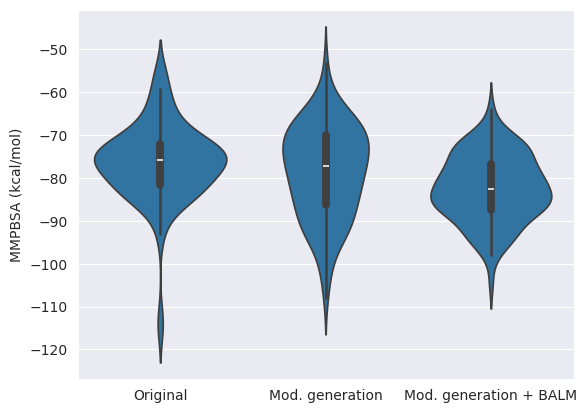

In [36]:
sns.violinplot(df_plot, x = "Origin", y = "delta_total")
plt.xlabel("")
plt.ylabel("MMPBSA (kcal/mol)")

In [37]:
df_plot.Origin.value_counts()

Origin
Mod. generation           108
Mod. generation + BALM    104
Original                   99
Name: count, dtype: int64

In [38]:
df_deploy2 = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_29_balm_deployed_weight_10_length_15/mpnn_design_stats_augmented_with_ntoc.csv")
df_deploy2.loc[:,"Origin"] = "Mod. generation + BALM"

df_plot2 = pd.concat([df_all.loc[df_all.Length == 15, :], df_deploy2])

/tmp/ipykernel_756589/1536226450.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_deploy2.loc[:,"Origin"] = "Mod. generation + BALM"


In [71]:
df_deploy2 = df_deploy2.dropna(subset = ["delta_total"])
corr_df = df_deploy2.corr(numeric_only = True)["delta_total"]

corr_df[corr_df > 0.1]

Average_pAE               0.171663
1_pAE                     0.145940
2_pAE                     0.182236
Average_i_pAE             0.148383
1_i_pAE                   0.141441
2_i_pAE                   0.192977
1_Unrelaxed_Clashes       0.104302
Average_PackStat          0.159017
1_PackStat                0.226654
Average_dG                0.376002
1_dG                      0.407015
2_dG                      0.272489
Average_dG/dSASA          0.168144
1_dG/dSASA                0.252471
Average_Binder_Loop%      0.223463
1_Binder_Loop%            0.200074
2_Binder_Loop%            0.228954
Average_Target_RMSD       0.125368
1_Target_RMSD             0.125572
2_Target_RMSD             0.124999
delta_total_accepted      1.000000
dG_binding_IE_accepted    0.364081
delta_total               1.000000
dG_binding_IE             0.364081
Y                         1.000000
n_to_c                    0.122528
Name: delta_total, dtype: float64

(98, 244)

98 rows, 33 Average_* features
   ['Average_pLDDT', 'Average_pTM', 'Average_i_pTM', 'Average_pAE', 'Average_i_pAE', 'Average_i_pLDDT', 'Average_ss_pLDDT', 'Average_Unrelaxed_Clashes', 'Average_Relaxed_Clashes', 'Average_Binder_Energy_Score', 'Average_Surface_Hydrophobicity', 'Average_ShapeComplementarity', 'Average_PackStat', 'Average_dG', 'Average_dSASA', 'Average_dG/dSASA', 'Average_Interface_SASA_%', 'Average_Interface_Hydrophobicity', 'Average_n_InterfaceResidues', 'Average_n_InterfaceHbonds', 'Average_InterfaceHbondsPercentage', 'Average_n_InterfaceUnsatHbonds', 'Average_InterfaceUnsatHbondsPercentage', 'Average_Interface_Helix%', 'Average_Interface_Loop%', 'Average_Binder_Helix%', 'Average_Binder_Loop%', 'Average_Hotspot_RMSD', 'Average_Target_RMSD', 'Average_Binder_pLDDT', 'Average_Binder_pTM', 'Average_Binder_pAE', 'Average_Binder_RMSD']
bottom-30% cutoff: delta_total <= -78.7010  (30 rows)
   coverage  density  id   k  mass     mean   n  res_dim
0       1.0  0.30137   0  22   

ValueError: No variables found for grid columns.

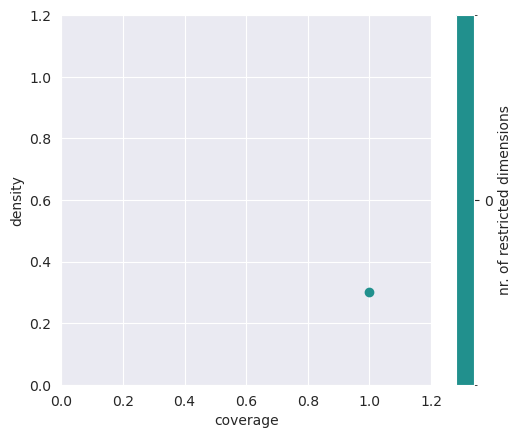

In [153]:
"""
PRIM bump-hunting + UMAP/PCA embeddings on df_deploy2_for_training.
Target: delta_total (we hunt the LOWEST 30%).

deps: pip install ema_workbench umap-learn scikit-learn matplotlib pandas
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

TARGET = "delta_total"
df = df_deploy2_for_training  # noqa: F821  (already in your session)

# ---------------------------------------------------------------- 1. numeric only
num = df.select_dtypes(include=[np.number]).copy()
num = num.dropna(subset=[TARGET])

y_raw = num[TARGET]

# only Average_* features -- keeps the search space small to limit overfitting.
# X feeds PRIM *and* the PCA/UMAP below, so this restriction applies to all three.
X = num[[c for c in num.columns if c.startswith("Average_")]]
if X.empty:
    raise ValueError("no Average_* numeric columns found -- check the prefix/case")

# drop constant / all-NaN columns, then impute the rest with the median
X = X.loc[:, X.nunique(dropna=True) > 1].copy()
X = X.fillna(X.median())

print(f"{X.shape[0]} rows, {X.shape[1]} Average_* features")
print("  ", list(X.columns))

# ---------------------------------------------------------------- 2. define "good"
thr = y_raw.quantile(0.30)
y_bin = (y_raw <= thr).astype(int)
print(f"bottom-30% cutoff: {TARGET} <= {thr:.4f}  ({y_bin.sum()} rows)")

# hold out a test set BEFORE searching, so we can check the box generalises
X_tr, X_te, ybin_tr, ybin_te, yraw_tr, yraw_te = train_test_split(
    X, y_bin, y_raw, test_size=0.25, random_state=0, stratify=y_bin
)

# ---------------------------------------------------------------- 3. PRIM
from ema_workbench.analysis import prim

# ema_workbench 3.0.0: no `threshold` arg any more, y is a plain binary array
alg = prim.Prim(X_tr, ybin_tr.values, peel_alpha=0.05, mass_min=0.05)
box = alg.find_box()

box.show_tradeoff()          # coverage vs density -- pick your point on this curve
plt.savefig("prim_tradeoff.png", dpi=150, bbox_inches="tight")

# the table version of that plot -- easier to pick from
print(box.peeling_trajectory)

# --- choose a peel -------------------------------------------------
# set PEEL from the trajectory above (high coverage, density you'll accept,
# and res_dim small -- each extra restricted dim is another chance to overfit)
PEEL = box._cur_box          # <-- replace with your chosen id
box.select(PEEL)
box.inspect(style="table")
box.show_pairs_scatter()
plt.savefig("prim_pairs.png", dpi=150, bbox_inches="tight")

lims = box.box_lims[box._cur_box]

def box_mask(frame, lims):
    m = pd.Series(True, index=frame.index)
    for col in lims.columns:
        lo, hi = lims[col].iloc[0], lims[col].iloc[1]
        m &= frame[col].between(lo, hi)
    return m

restricted = [c for c in lims.columns
              if (lims[c].iloc[0] > X[c].min()) or (lims[c].iloc[1] < X[c].max())]
print("\n=== FILTER ===")
for c in restricted:
    print(f"  {lims[c].iloc[0]:.4g} <= {c} <= {lims[c].iloc[1]:.4g}")

for name, Xs, ys in [("train", X_tr, yraw_tr), ("HOLDOUT", X_te, yraw_te)]:
    m = box_mask(Xs, lims)
    print(f"{name:8s} n={m.sum():5d} ({m.mean():5.1%})  "
          f"mean {TARGET}={ys[m].mean():.4f} vs {ys.mean():.4f} overall  "
          f"| precision={(ys[m] <= thr).mean():.1%}")

# ---------------------------------------------------------------- 4. PCA + UMAP
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)
emb_pca = pca.fit_transform(Xs)

import umap
emb_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(Xs)

# colour by rank of delta_total so outliers don't wash out the palette
c = y_raw.rank(pct=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, title in [
    (axes[0], emb_pca,
     f"PCA ({pca.explained_variance_ratio_.sum():.0%} var)"),
    (axes[1], emb_umap, "UMAP"),
]:
    s = ax.scatter(emb[:, 0], emb[:, 1], c=c, cmap="viridis", s=6, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
fig.colorbar(s, ax=axes, label=f"{TARGET} (percentile rank)")
plt.savefig("embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

# same embeddings, highlighting where the PRIM box lands
mask_all = box_mask(X, lims)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, title in [(axes[0], emb_pca, "PCA"), (axes[1], emb_umap, "UMAP")]:
    ax.scatter(emb[~mask_all.values, 0], emb[~mask_all.values, 1],
               c="lightgrey", s=5, alpha=0.5, label="outside box")
    ax.scatter(emb[mask_all.values, 0], emb[mask_all.values, 1],
               c="crimson", s=8, label="in PRIM box")
    ax.set_title(title); ax.legend()
plt.savefig("embeddings_box.png", dpi=150, bbox_inches="tight")
plt.show()

In [155]:
print(X_tr.shape, list(X_tr.columns))
print(ybin_tr.dtype, ybin_tr.sum(), len(ybin_tr))
print(box.peeling_trajectory)

(73, 33) ['Average_pLDDT', 'Average_pTM', 'Average_i_pTM', 'Average_pAE', 'Average_i_pAE', 'Average_i_pLDDT', 'Average_ss_pLDDT', 'Average_Unrelaxed_Clashes', 'Average_Relaxed_Clashes', 'Average_Binder_Energy_Score', 'Average_Surface_Hydrophobicity', 'Average_ShapeComplementarity', 'Average_PackStat', 'Average_dG', 'Average_dSASA', 'Average_dG/dSASA', 'Average_Interface_SASA_%', 'Average_Interface_Hydrophobicity', 'Average_n_InterfaceResidues', 'Average_n_InterfaceHbonds', 'Average_InterfaceHbondsPercentage', 'Average_n_InterfaceUnsatHbonds', 'Average_InterfaceUnsatHbondsPercentage', 'Average_Interface_Helix%', 'Average_Interface_Loop%', 'Average_Binder_Helix%', 'Average_Binder_Loop%', 'Average_Hotspot_RMSD', 'Average_Target_RMSD', 'Average_Binder_pLDDT', 'Average_Binder_pTM', 'Average_Binder_pAE', 'Average_Binder_RMSD']
int64 22 73
   coverage  density  id   k  mass     mean   n  res_dim
0       1.0  0.30137   0  22   1.0  0.30137  73        0


In [152]:
import ema_workbench, inspect
print(ema_workbench.__version__, inspect.signature(prim.Prim.__init__))

3.0.0 (self, x: pandas.DataFrame, y: numpy.ndarray, obj_function: Literal[<PRIMObjectiveFunctions.LENIENT1: 'lenient1'>, <PRIMObjectiveFunctions.LENIENT2: 'lenient2'>, <PRIMObjectiveFunctions.ORIGINAL: 'original'>] = <PRIMObjectiveFunctions.LENIENT1: 'lenient1'>, peel_alpha: float = 0.05, paste_alpha: float = 0.05, mass_min: float = 0.05, update_function: Literal['default', 'guivarch'] = 'default')


In [144]:
df_deploy2_for_training = df_deploy2.iloc[:, :-6]
df_deploy2_for_training

,Design,Protocol,Length,Seed,Helicity,Target_Hotspot,Sequence,InterfaceResidues,MPNN_score,MPNN_seq_recovery,...,delta_total_rejected,dG_binding_IE_rejected,dG_binding_IE_err_rejected,Target_accepted,proteina_accepted,Target_rejected,proteina_rejected,Target,proteina,delta_total
7,BAX_1F16_l15_s392931_mpnn4,4stage,15,392931,0.95,74-99,MEEDIQKLIEFMRNW,"B1,B2,B4,B5,B7,B8,B9,B11,B12,B13,B14,B15",1.25,0.18,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEEDIQKLIEFMRNW,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEEDIQKLIEFMRNW,-70.08
8,BAX_1F16_l15_s392931_mpnn6,4stage,15,392931,0.95,74-99,MEADIKKLVEFMRNW,"B1,B2,B4,B5,B7,B8,B9,B11,B12,B13,B14,B15",1.27,0.27,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEADIKKLVEFMRNW,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEADIKKLVEFMRNW,-67.04
12,BAX_1F16_l15_s23990_mpnn1,4stage,15,23990,0.95,74-99,SKWIELLLKEIESLR,"B1,B2,B3,B4,B6,B7,B8,B10,B11,B12,B14,B15",1.01,0.27,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,SKWIELLLKEIESLR,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,SKWIELLLKEIESLR,-71.49
14,BAX_1F16_l15_s23990_mpnn2,4stage,15,23990,0.95,74-99,SKWIELLLKEIESLQ,"B1,B2,B3,B4,B6,B7,B8,B10,B11,B12,B14,B15",1.04,0.18,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,SKWIELLLKEIESLQ,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,SKWIELLLKEIESLQ,-66.10
29,BAX_1F16_l15_s732938_mpnn1,4stage,15,732938,0.95,74-99,RPEEQATVMRNVADM,"B1,B2,B3,B5,B6,B8,B9,B10,B11,B12,B13,B14,B15",1.30,0.75,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,RPEEQATVMRNVADM,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,RPEEQATVMRNVADM,-63.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,BAX_1F16_l15_s615356_mpnn2,4stage,15,615356,0.95,74-99,FQELADMVQKKMEAW,"B1,B2,B3,B4,B5,B6,B7,B8,B9,B11,B12,B13,B15",1.38,0.00,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,FQELADMVQKKMEAW,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,FQELADMVQKKMEAW,-85.23
709,BAX_1F16_l15_s693305_mpnn1,4stage,15,693305,0.95,74-99,MEKWREVMDHIVSLY,"B1,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B14,B15",1.01,0.14,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEKWREVMDHIVSLY,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,MEKWREVMDHIVSLY,-76.33
711,BAX_1F16_l15_s989099_mpnn1,4stage,15,989099,0.95,74-99,DDIGRKIAEMVESRF,"B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B14,B15",0.99,0.50,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,DDIGRKIAEMVESRF,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,DDIGRKIAEMVESRF,-80.98
714,BAX_1F16_l15_s989099_mpnn2,4stage,15,989099,0.95,74-99,DDIGRRIAEMVLSRF,"B1,B2,B3,B4,B5,B6,B7,B8,B10,B11,B12,B13,B14,B15",1.02,0.43,...,NaN,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,DDIGRRIAEMVLSRF,NaN,NaN,MDGSGEQPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELA...,DDIGRRIAEMVLSRF,-71.19


(37, 250)

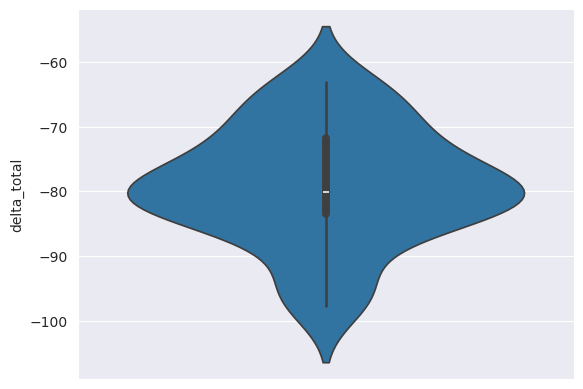

In [234]:
df_deploy2_filtered = df_deploy2.loc[(
                                        df_deploy2.Average_dG < -45)
                                    # & ( df_deploy2.Average_dSASA < 10)
                                     & (df_deploy2.Average_dSASA > 1500)
                                     & (df_deploy2.Average_PackStat < 0.62)
                                     &  (df_deploy2.Average_pLDDT > 0.86)
                                        ]
#df_deploy2.shape
sns.violinplot(df_deploy2_filtered, y = "delta_total")
df_deploy2_filtered.shape

In [206]:
df_deploy2_filtered.corr(numeric_only = True)["delta_total"]

Length                    NaN
Seed                -0.119248
Helicity                  NaN
MPNN_score          -0.301247
MPNN_seq_recovery    0.096126
                       ...   
delta_total          1.000000
dG_binding_IE        0.356153
dG_binding_IE_err   -0.223891
Y                    1.000000
n_to_c               0.161837
Name: delta_total, Length: 231, dtype: float64

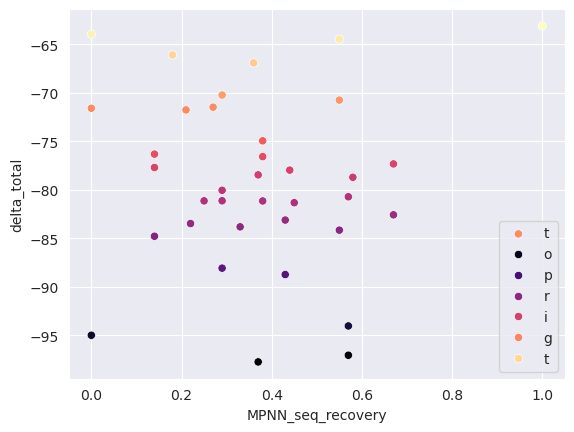

In [230]:

sns.scatterplot(df_deploy2_filtered, x = "MPNN_seq_recovery", y= "delta_total", hue = "delta_total", palette = "magma")
plt.legend("toprigth")
#plt.xlim([0,3])

In [41]:
df_plot2 = df_plot2.dropna(subset = ["delta_total"])

In [42]:
df_plot2.delta_total.max()

np.float64(-50.01)

ValueError: cannot reindex on an axis with duplicate labels

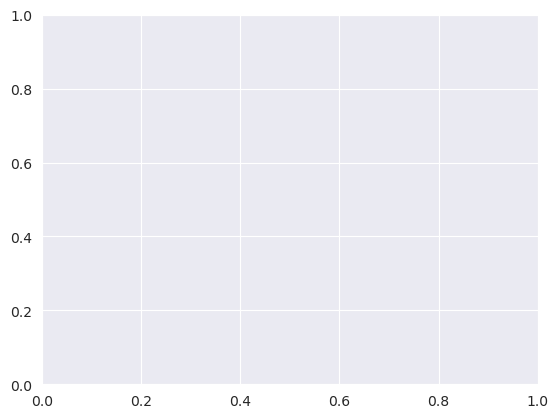

In [43]:
sns.violinplot(df_all.loc[df_all.Length == 15, :], x = "n_to_c", y = "delta_total")
plt.xlabel("")
plt.ylabel("MMPBSA (kcal/mol)")

In [16]:
df_deploy2.n_to_c.value_counts()

n_to_c
0    513
1    212
Name: count, dtype: int64

Text(0, 0.5, 'dSASA')

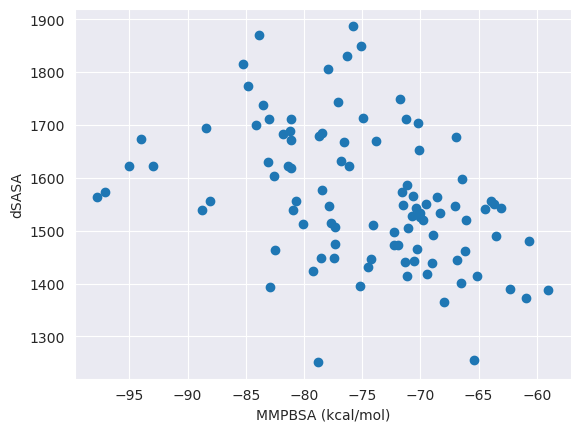

In [13]:
plt.scatter(df_deploy2.delta_total, df_deploy2.Average_dSASA)
plt.xlabel("MMPBSA (kcal/mol)")
plt.ylabel("dSASA")
